c:\Users\aida-lab\AppData\Local\anaconda3\envs\tf_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 714M/714M [02:16<00:00, 5.47MB/s] 

Extracting files...


Found 7858 image-mask pairs
Epoch 1/50
20/20 [==============================] - 27s 227ms/step - loss: 0.2103 - accuracy: 0.9905 - val_loss: 0.0426 - val_accuracy: 0.9900
Epoch 2/50
20/20 [==============================] - 5s 248ms/step - loss: 0.0368 - accuracy: 0.9917 - val_loss: 0.0446 - val_accuracy: 0.9900
Epoch 3/50
20/20 [==============================] - 5s 240ms/step - loss: 0.0358 - accuracy: 0.9917 - val_loss: 0.0384 - val_accuracy: 0.9900
Epoch 4/50
20/20 [==============================] - 5s 245ms/step - loss: 0.0334 - accuracy: 0.9917 - val_loss: 0.0385 - val_accuracy: 0.9900
Epoch 5/50
20/20 [==============================] - 5s 239ms/step - loss: 0.0324 - accuracy: 0.9917 - val_loss: 0.0377 - val_accuracy: 0.9900
Epoch 6/50
20/20 [==============================] - 3s 144ms/step - loss: 0.0316 - accuracy: 0.9917 - val_loss: 0.0489 - val_accuracy: 0.9900
Epoch 7/50
20/20 [==============================] - 2s 113ms/step - loss: 0.0329 - accuracy: 0.9917 - val_loss: 0.0371 

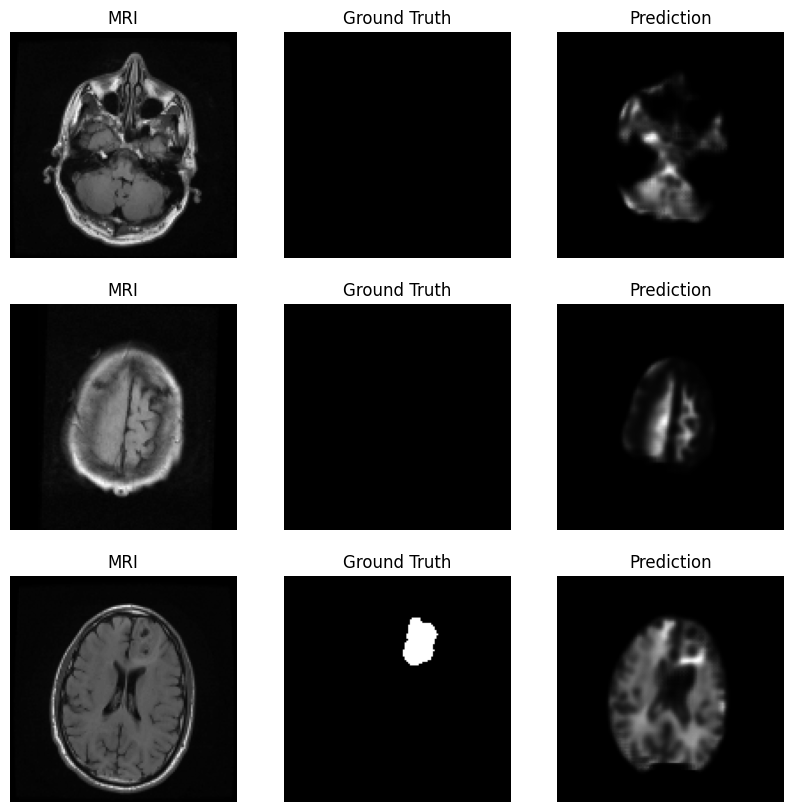

In [1]:

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
base = Path(path)
pairs = []
for img in base.rglob('*.tif'):
    if '_mask' not in img.name:
        mask = img.parent / img.name.replace('.tif', '_mask.tif')
        if mask.exists():
            pairs.append((img, mask))

print(f"Found {len(pairs)} image-mask pairs")
IMG_SIZE = 128
X, Y = [], []
for img_path, mask_path in pairs[:500]:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if img is not None and mask is not None:
        X.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
        Y.append(cv2.resize(mask, (IMG_SIZE, IMG_SIZE)))
X = np.array(X)[..., np.newaxis] / 255.0
Y = np.array(Y)[..., np.newaxis] / 255.0
Y = (Y > 0.5).astype(np.float32)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
def double_conv(x, filters):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    return x

def unet(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    c1 = double_conv(inputs, 64)
    p1 = layers.MaxPooling2D(2)(c1)
    
    c2 = double_conv(p1, 128)
    p2 = layers.MaxPooling2D(2)(c2)
    
    # Bottleneck
    c3 = double_conv(p2, 256)
    u4 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = double_conv(u4, 128)
    
    u5 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = double_conv(u5, 64)
    
    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)
    return models.Model(inputs, outputs)

# Initialize and compile the model
model = unet((IMG_SIZE, IMG_SIZE, 1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, Y_train, epochs=50, validation_split=0.2, batch_size=16)

# Evaluate the model
loss, acc = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

# Prediction and Visualization
Y_pred = model.predict(X_test[:3])

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    # Original MRI
    axes[i, 0].imshow(X_test[i, :, :, 0], cmap='gray')
    axes[i, 0].set_title('MRI')
    
    # Ground Truth Mask
    axes[i, 1].imshow(Y_test[i, :, :, 0], cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    
    # Model Prediction
    axes[i, 2].imshow(Y_pred[i, :, :, 0], cmap='gray')
    axes[i, 2].set_title('Prediction')
    for j in range(3): 
        axes[i, j].axis('off')

plt.show()